In [1]:
!pip uninstall -y diffusers transformers tokenizers accelerate huggingface_hub -q

!pip install -q \
    diffusers==0.29.2 \
    transformers==4.48.3 \
    tokenizers==0.21.0 \
    accelerate==1.2.1 \
    huggingface_hub==0.33.5 \
    safetensors \
    torchmetrics \
    torch-fidelity \
    lpips

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.4/44.4 kB 2.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.2/2.2 MB 42.4 MB/s eta 0:00:0000:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.7/9.7 MB 113.2 MB/s eta 0:00:0000:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.0/3.0 MB 80.8 MB/s eta 0:00:00:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 336.4/336.4 kB 24.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 515.7/515.7 kB 34.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 85.6/85.6 kB 6.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 53.8/53.8 kB 3.7 MB/s eta 0:00:00


In [ ]:
import os
os._exit(0)

In [1]:
import os
import io
import json
import time
import math
import random
import zipfile
from pathlib import Path

import numpy as np
import pandas as pd
from PIL import Image, ImageDraw, ImageFilter
import matplotlib.pyplot as plt
from tqdm import tqdm

import torch
from torch.utils.data import Dataset
from torchvision import transforms, utils

from diffusers import StableDiffusionInpaintPipeline

The cache for model files in Transformers v4.22.0 has been updated. Migrating your old cache. This is a one-time only operation. You can interrupt this and resume the migration later on by calling `transformers.utils.move_cache()`.


0it [00:00, ?it/s]

2026-04-08 11:54:49.837822: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1775649290.068880     116 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1775649290.130003     116 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1775649290.663370     116 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1775649290.663407     116 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1775649290.663409     116 computation_placer.cc:177] computation placer alr

In [2]:
def seed_all(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    os.environ["PYTHONHASHSEED"] = str(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

seed_all(42)

device = "cuda" if torch.cuda.is_available() else "cpu"
print("Device:", device)
print("Torch version:", torch.__version__)

Device: cuda
Torch version: 2.10.0+cu128


In [7]:
# Change only if your Kaggle dataset path is different
DATA_ROOT = Path("/kaggle/input/datasets/jessicali9530/celeba-dataset/img_align_celeba/img_align_celeba")

WORK_ROOT   = Path("/kaggle/working/teacher_baseline_sd2_celeba_inpainting")
RESULT_DIR  = WORK_ROOT / "results"
SAMPLE_DIR  = WORK_ROOT / "samples"
META_DIR    = WORK_ROOT / "metadata"
ZIP_DIR     = WORK_ROOT / "zips"
INDIV_DIR   = SAMPLE_DIR / "individual_outputs"
GRID_DIR    = SAMPLE_DIR / "grids"

for p in [RESULT_DIR, SAMPLE_DIR, META_DIR, ZIP_DIR, INDIV_DIR, GRID_DIR]:
    p.mkdir(parents=True, exist_ok=True)

print("DATA_ROOT :", DATA_ROOT)
print("WORK_ROOT :", WORK_ROOT)

DATA_ROOT : /kaggle/input/datasets/jessicali9530/celeba-dataset/img_align_celeba/img_align_celeba
WORK_ROOT : /kaggle/working/teacher_baseline_sd2_celeba_inpainting


In [8]:
CFG = {
    "image_size": 512,
    "subset": {
        "train_size": 10000,
        "val_size": 1000,
        "test_size": 1000,
        "seed": 42,
        "manifest_name": "celeba_fixed_subset_manifest.json"
    },
    "teacher": {
        "model_id": "sd2-community/stable-diffusion-2-inpainting",
        "num_inference_steps": 30,
        "guidance_scale": 7.5,
        "strength": 1.0,
        "prompt": "a realistic high-quality human face"
    },
    "eval": {
        "n_test_samples_for_inference": 64,
        "save_grid_count": 8,
        "save_individual_count": 24,
        "n_eval_metrics": 300
    },
    "masking": {
        "rect_prob": 0.30,
        "brush_prob": 0.30,
        "center_prob": 0.15,
        "blob_prob": 0.25,

        "min_holes": 1,
        "max_holes": 4,
        "min_size": 40,
        "max_size": 180,

        "brush_width_min": 12,
        "brush_width_max": 40,
        "brush_strokes_min": 1,
        "brush_strokes_max": 4,
        "points_per_stroke_min": 4,
        "points_per_stroke_max": 8,

        "blob_count_min": 2,
        "blob_count_max": 6,
        "blob_radius_min": 20,
        "blob_radius_max": 80,

        "mask_area_min_ratio": 0.05,
        "mask_area_max_ratio": 0.45
    }
}

In [9]:
all_image_paths = sorted([
    p for p in DATA_ROOT.glob("*")
    if p.is_file() and p.suffix.lower() in [".jpg", ".jpeg", ".png", ".webp"]
])

print("Total images found:", len(all_image_paths))
print("First 5 image names:", [p.name for p in all_image_paths[:5]])

Total images found: 202599
First 5 image names: ['000001.jpg', '000002.jpg', '000003.jpg', '000004.jpg', '000005.jpg']


In [10]:
manifest_path = META_DIR / CFG["subset"]["manifest_name"]

def create_fixed_subset_manifest(image_paths, cfg_subset, manifest_path):
    n = len(image_paths)
    train_size = cfg_subset["train_size"]
    val_size = cfg_subset["val_size"]
    test_size = cfg_subset["test_size"]
    seed = cfg_subset["seed"]

    total_needed = train_size + val_size + test_size
    if total_needed > n:
        raise ValueError(f"Requested {total_needed} images, but only found {n}")

    filenames = [p.name for p in image_paths]
    rng = random.Random(seed)
    rng.shuffle(filenames)

    train_files = filenames[:train_size]
    val_files = filenames[train_size:train_size + val_size]
    test_files = filenames[train_size + val_size:train_size + val_size + test_size]

    manifest = {
        "seed": seed,
        "train_size": train_size,
        "val_size": val_size,
        "test_size": test_size,
        "train_files": train_files,
        "val_files": val_files,
        "test_files": test_files
    }

    with open(manifest_path, "w") as f:
        json.dump(manifest, f, indent=2)

    return manifest

if manifest_path.exists():
    with open(manifest_path, "r") as f:
        manifest = json.load(f)
    print("Loaded existing fixed subset manifest.")
else:
    manifest = create_fixed_subset_manifest(all_image_paths, CFG["subset"], manifest_path)
    print("Created new fixed subset manifest.")

print("Manifest saved at:", manifest_path)
print("Train:", len(manifest["train_files"]))
print("Val  :", len(manifest["val_files"]))
print("Test :", len(manifest["test_files"]))

Created new fixed subset manifest.
Manifest saved at: /kaggle/working/teacher_baseline_sd2_celeba_inpainting/metadata/celeba_fixed_subset_manifest.json
Train: 10000
Val  : 1000
Test : 1000


In [11]:
subset_csv_path = META_DIR / "celeba_fixed_subset_filenames.csv"

rows = []
for split_name in ["train_files", "val_files", "test_files"]:
    split_tag = split_name.replace("_files", "")
    for fname in manifest[split_name]:
        rows.append({"split": split_tag, "filename": fname})

df_subset = pd.DataFrame(rows)
df_subset.to_csv(subset_csv_path, index=False)

print("Saved subset CSV:", subset_csv_path)
df_subset.head()

Saved subset CSV: /kaggle/working/teacher_baseline_sd2_celeba_inpainting/metadata/celeba_fixed_subset_filenames.csv


,split,filename
0,train,020294.jpg
1,train,179427.jpg
2,train,023999.jpg
3,train,138391.jpg
4,train,104869.jpg


In [12]:
DO_ZIP_METADATA = True
meta_zip_path = ZIP_DIR / "celeba_fixed_subset_metadata.zip"

if DO_ZIP_METADATA:
    with zipfile.ZipFile(meta_zip_path, "w", compression=zipfile.ZIP_DEFLATED) as zf:
        if manifest_path.exists():
            zf.write(manifest_path, arcname=manifest_path.name)
        if subset_csv_path.exists():
            zf.write(subset_csv_path, arcname=subset_csv_path.name)
    print("Saved metadata zip:", meta_zip_path)
else:
    print("Skipping metadata zip.")

Saved metadata zip: /kaggle/working/teacher_baseline_sd2_celeba_inpainting/zips/celeba_fixed_subset_metadata.zip


In [13]:
class FixedSubsetImageDataset(Dataset):
    def __init__(self, data_root, filenames, image_size=512):
        self.data_root = Path(data_root)
        self.filenames = filenames
        self.transform = transforms.Compose([
            transforms.Resize((image_size, image_size))
        ])

    def __len__(self):
        return len(self.filenames)

    def __getitem__(self, idx):
        fname = self.filenames[idx]
        path = self.data_root / fname
        img = Image.open(path).convert("RGB")
        img = self.transform(img)
        return {
            "filename": fname,
            "image_pil": img
        }

train_ds = FixedSubsetImageDataset(DATA_ROOT, manifest["train_files"], image_size=CFG["image_size"])
val_ds   = FixedSubsetImageDataset(DATA_ROOT, manifest["val_files"], image_size=CFG["image_size"])
test_ds  = FixedSubsetImageDataset(DATA_ROOT, manifest["test_files"], image_size=CFG["image_size"])

print("Train:", len(train_ds))
print("Val  :", len(val_ds))
print("Test :", len(test_ds))

Train: 10000
Val  : 1000
Test : 1000


In [14]:
def make_rectangle_mask_pil(size, cfg):
    w, h = size
    mask = Image.new("L", (w, h), 0)
    draw = ImageDraw.Draw(mask)

    n_holes = random.randint(cfg["min_holes"], cfg["max_holes"])
    for _ in range(n_holes):
        hole_w = random.randint(cfg["min_size"], min(cfg["max_size"], w // 2))
        hole_h = random.randint(cfg["min_size"], min(cfg["max_size"], h // 2))
        x1 = random.randint(0, w - hole_w)
        y1 = random.randint(0, h - hole_h)
        x2 = x1 + hole_w
        y2 = y1 + hole_h
        draw.rectangle([x1, y1, x2, y2], fill=255)

    return mask

In [15]:
def make_center_mask_pil(size):
    w, h = size
    mask = Image.new("L", (w, h), 0)
    draw = ImageDraw.Draw(mask)

    box_w = int(w * 0.4)
    box_h = int(h * 0.4)
    x1 = (w - box_w) // 2
    y1 = (h - box_h) // 2
    x2 = x1 + box_w
    y2 = y1 + box_h

    draw.rectangle([x1, y1, x2, y2], fill=255)
    return mask

In [16]:
def make_brush_mask_pil(size, cfg):
    w, h = size
    mask = Image.new("L", (w, h), 0)
    draw = ImageDraw.Draw(mask)

    n_strokes = random.randint(cfg["brush_strokes_min"], cfg["brush_strokes_max"])
    for _ in range(n_strokes):
        n_points = random.randint(cfg["points_per_stroke_min"], cfg["points_per_stroke_max"])
        points = []
        for _ in range(n_points):
            x = random.randint(0, w - 1)
            y = random.randint(0, h - 1)
            points.append((x, y))

        width = random.randint(cfg["brush_width_min"], cfg["brush_width_max"])
        draw.line(points, fill=255, width=width)

        for px, py in points:
            r = width // 2
            draw.ellipse((px-r, py-r, px+r, py+r), fill=255)

    return mask

In [17]:
def make_blob_mask_pil(size, cfg):
    w, h = size
    mask = Image.new("L", (w, h), 0)
    draw = ImageDraw.Draw(mask)

    n_blobs = random.randint(cfg["blob_count_min"], cfg["blob_count_max"])

    for _ in range(n_blobs):
        cx = random.randint(0, w - 1)
        cy = random.randint(0, h - 1)
        rx = random.randint(cfg["blob_radius_min"], cfg["blob_radius_max"])
        ry = random.randint(cfg["blob_radius_min"], cfg["blob_radius_max"])

        x1 = max(0, cx - rx)
        y1 = max(0, cy - ry)
        x2 = min(w - 1, cx + rx)
        y2 = min(h - 1, cy + ry)

        draw.ellipse([x1, y1, x2, y2], fill=255)

    mask = mask.filter(ImageFilter.GaussianBlur(radius=6))
    mask_np = np.array(mask)
    mask_np = (mask_np > 80).astype(np.uint8) * 255
    return Image.fromarray(mask_np, mode="L")

In [18]:
def mask_area_ratio(mask_pil):
    mask_np = np.array(mask_pil)
    return float((mask_np > 127).mean())

def sample_hybrid_mask_pil(size, cfg, max_tries=20):
    probs = [
        ("rect", cfg["rect_prob"]),
        ("brush", cfg["brush_prob"]),
        ("center", cfg["center_prob"]),
        ("blob", cfg["blob_prob"])
    ]

    labels = [x[0] for x in probs]
    weights = [x[1] for x in probs]

    for _ in range(max_tries):
        mask_type = random.choices(labels, weights=weights, k=1)[0]

        if mask_type == "rect":
            mask = make_rectangle_mask_pil(size, cfg)
        elif mask_type == "brush":
            mask = make_brush_mask_pil(size, cfg)
        elif mask_type == "center":
            mask = make_center_mask_pil(size)
        else:
            mask = make_blob_mask_pil(size, cfg)

        area = mask_area_ratio(mask)
        if cfg["mask_area_min_ratio"] <= area <= cfg["mask_area_max_ratio"]:
            return mask, mask_type, area

    mask = make_center_mask_pil(size)
    return mask, "center_fallback", mask_area_ratio(mask)

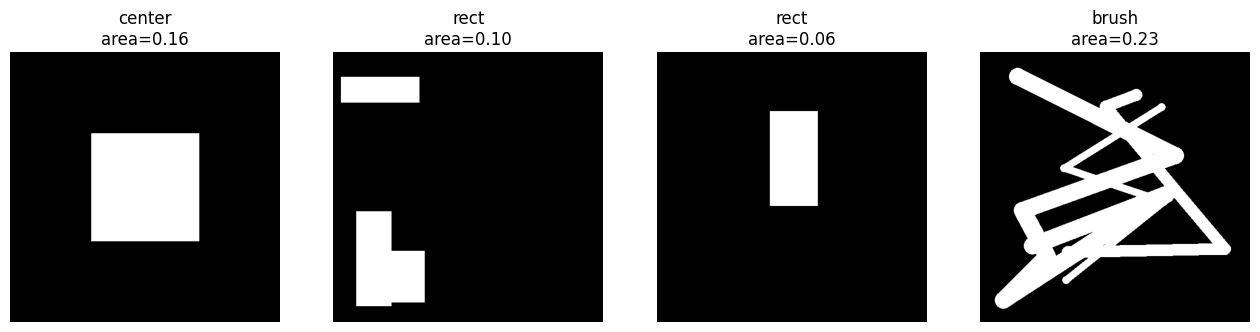

In [19]:
sample_img = test_ds[0]["image_pil"]

plt.figure(figsize=(16, 4))
for i in range(4):
    m, mtype, area = sample_hybrid_mask_pil(sample_img.size, CFG["masking"])
    plt.subplot(1, 4, i+1)
    plt.imshow(m, cmap="gray")
    plt.axis("off")
    plt.title(f"{mtype}\narea={area:.2f}")
plt.show()

In [20]:
def apply_mask_to_image(image_pil, mask_pil):
    image_np = np.array(image_pil).copy()
    mask_np = np.array(mask_pil)
    masked_np = image_np.copy()
    masked_np[mask_np > 127] = 0
    return Image.fromarray(masked_np)

In [21]:
teacher = StableDiffusionInpaintPipeline.from_pretrained(
    CFG["teacher"]["model_id"],
    torch_dtype=torch.float16 if device == "cuda" else torch.float32,
    safety_checker=None
)

teacher = teacher.to(device)

if device == "cuda":
    try:
        teacher.enable_attention_slicing()
        print("Enabled attention slicing.")
    except Exception as e:
        print("Attention slicing not enabled:", e)

print("Teacher loaded.")

model_index.json:   0%|          | 0.00/544 [00:00<?, ?B/s]

Fetching 13 files:   0%|          | 0/13 [00:00<?, ?it/s]

config.json:   0%|          | 0.00/638 [00:00<?, ?B/s]

preprocessor_config.json:   0%|          | 0.00/342 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/829 [00:00<?, ?B/s]

...

config.json:   0%|          | 0.00/616 [00:00<?, ?B/s]

unet/diffusion_pytorch_model.safetensors:   0%|          | 0.00/3.46G [00:00<?, ?B/s]

vae/diffusion_pytorch_model.safetensors:   0%|          | 0.00/335M [00:00<?, ?B/s]

Loading pipeline components...:   0%|          | 0/6 [00:00<?, ?it/s]

Enabled attention slicing.
Teacher loaded.


In [22]:
@torch.no_grad()
def run_teacher_inpaint(pipe, image_pil, mask_pil, cfg_teacher):
    out = pipe(
        prompt=cfg_teacher["prompt"],
        image=image_pil,
        mask_image=mask_pil,
        num_inference_steps=cfg_teacher["num_inference_steps"],
        guidance_scale=cfg_teacher["guidance_scale"],
        strength=cfg_teacher["strength"]
    )
    return out.images[0]

  0%|          | 0/30 [00:00<?, ?it/s]

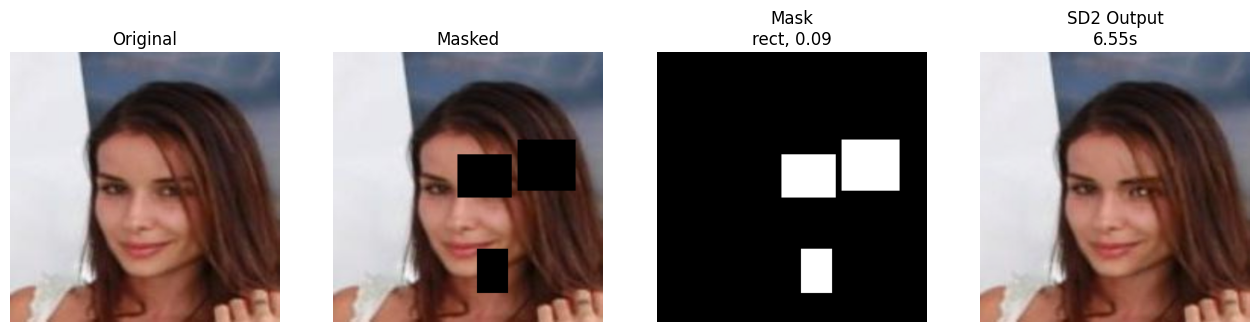

In [23]:
sample = test_ds[0]
orig = sample["image_pil"]
mask, mask_type, area = sample_hybrid_mask_pil(orig.size, CFG["masking"])
masked = apply_mask_to_image(orig, mask)

start = time.time()
pred = run_teacher_inpaint(teacher, orig, mask, CFG["teacher"])
elapsed = time.time() - start

plt.figure(figsize=(16, 4))

plt.subplot(1, 4, 1)
plt.imshow(orig)
plt.title("Original")
plt.axis("off")

plt.subplot(1, 4, 2)
plt.imshow(masked)
plt.title("Masked")
plt.axis("off")

plt.subplot(1, 4, 3)
plt.imshow(mask, cmap="gray")
plt.title(f"Mask\n{mask_type}, {area:.2f}")
plt.axis("off")

plt.subplot(1, 4, 4)
plt.imshow(pred)
plt.title(f"SD2 Output\n{elapsed:.2f}s")
plt.axis("off")

plt.show()

In [24]:
def pil_to_tensor_01(img):
    arr = np.array(img).astype(np.float32) / 255.0
    if arr.ndim == 2:
        arr = np.stack([arr, arr, arr], axis=-1)
    t = torch.from_numpy(arr).permute(2, 0, 1)
    return t

In [25]:
n_eval = min(CFG["eval"]["n_test_samples_for_inference"], len(test_ds))
save_grid_count = min(CFG["eval"]["save_grid_count"], n_eval)
save_individual_count = min(CFG["eval"]["save_individual_count"], n_eval)

records = []
grid_items = []

for i in tqdm(range(n_eval), desc="SD2 baseline inference"):
    sample = test_ds[i]
    fname = sample["filename"]
    orig = sample["image_pil"]

    mask, mask_type, area = sample_hybrid_mask_pil(orig.size, CFG["masking"])
    masked = apply_mask_to_image(orig, mask)

    start = time.time()
    pred = run_teacher_inpaint(teacher, orig, mask, CFG["teacher"])
    elapsed = time.time() - start

    if i < save_individual_count:
        orig_path   = INDIV_DIR / f"{i:04d}_{Path(fname).stem}_orig.png"
        masked_path = INDIV_DIR / f"{i:04d}_{Path(fname).stem}_masked.png"
        mask_path   = INDIV_DIR / f"{i:04d}_{Path(fname).stem}_mask.png"
        pred_path   = INDIV_DIR / f"{i:04d}_{Path(fname).stem}_pred.png"

        orig.save(orig_path)
        masked.save(masked_path)
        mask.save(mask_path)
        pred.save(pred_path)
    else:
        orig_path = ""
        masked_path = ""
        mask_path = ""
        pred_path = ""

    records.append({
        "index": i,
        "filename": fname,
        "mask_type": mask_type,
        "mask_area_ratio": round(area, 4),
        "inference_time_sec": round(elapsed, 4),
        "orig_path": str(orig_path),
        "masked_path": str(masked_path),
        "mask_path": str(mask_path),
        "pred_path": str(pred_path)
    })

    if i < save_grid_count:
        grid_items.append((orig, masked, mask.convert("RGB"), pred, mask_type, area))

df_records = pd.DataFrame(records)
result_csv = RESULT_DIR / "sd2_baseline_inference_log.csv"
df_records.to_csv(result_csv, index=False)

print("Saved inference log:", result_csv)
df_records.head()

SD2 baseline inference:   0%|          | 0/64 [00:00<?, ?it/s]/tmp/ipykernel_116/2716138634.py:24: DeprecationWarning: 'mode' parameter is deprecated and will be removed in Pillow 13 (2026-10-15)
  return Image.fromarray(mask_np, mode="L")


  0%|          | 0/30 [00:00<?, ?it/s]

SD2 baseline inference:   2%|▏         | 1/64 [00:05<05:49,  5.55s/it]

  0%|          | 0/30 [00:00<?, ?it/s]

SD2 baseline inference:   3%|▎         | 2/64 [00:11<05:43,  5.54s/it]

...

SD2 baseline inference:  98%|█████████▊| 63/64 [06:12<00:05,  5.90s/it]

  0%|          | 0/30 [00:00<?, ?it/s]

SD2 baseline inference: 100%|██████████| 64/64 [06:18<00:00,  5.91s/it]

Saved inference log: /kaggle/working/teacher_baseline_sd2_celeba_inpainting/results/sd2_baseline_inference_log.csv


,index,filename,mask_type,mask_area_ratio,inference_time_sec,orig_path,masked_path,mask_path,pred_path
0,0,185385.jpg,blob,0.1893,5.2888,/kaggle/working/teacher_baseline_sd2_celeba_in...,/kaggle/working/teacher_baseline_sd2_celeba_in...,/kaggle/working/teacher_baseline_sd2_celeba_in...,/kaggle/working/teacher_baseline_sd2_celeba_in...
1,1,126390.jpg,blob,0.0909,5.2848,/kaggle/working/teacher_baseline_sd2_celeba_in...,/kaggle/working/teacher_baseline_sd2_celeba_in...,/kaggle/working/teacher_baseline_sd2_celeba_in...,/kaggle/working/teacher_baseline_sd2_celeba_in...
2,2,093644.jpg,rect,0.1376,5.3118,/kaggle/working/teacher_baseline_sd2_celeba_in...,/kaggle/working/teacher_baseline_sd2_celeba_in...,/kaggle/working/teacher_baseline_sd2_celeba_in...,/kaggle/working/teacher_baseline_sd2_celeba_in...
3,3,112214.jpg,blob,0.0813,5.3465,/kaggle/working/teacher_baseline_sd2_celeba_in...,/kaggle/working/teacher_baseline_sd2_celeba_in...,/kaggle/working/teacher_baseline_sd2_celeba_in...,/kaggle/working/teacher_baseline_sd2_celeba_in...
4,4,088630.jpg,blob,0.2408,5.3531,/kaggle/working/teacher_baseline_sd2_celeba_in...,/kaggle/working/teacher_baseline_sd2_celeba_in...,/kaggle/working/teacher_baseline_sd2_celeba_in...,/kaggle/working/teacher_baseline_sd2_celeba_in...


In [26]:
grid_tensors = []
for orig, masked, mask_rgb, pred, _, _ in grid_items:
    grid_tensors.extend([
        pil_to_tensor_01(orig),
        pil_to_tensor_01(masked),
        pil_to_tensor_01(mask_rgb),
        pil_to_tensor_01(pred)
    ])

grid = utils.make_grid(torch.stack(grid_tensors), nrow=4)
grid_path = GRID_DIR / "sd2_baseline_grid_main.png"
utils.save_image(grid, grid_path)

print("Saved main grid:", grid_path)

Saved main grid: /kaggle/working/teacher_baseline_sd2_celeba_inpainting/samples/grids/sd2_baseline_grid_main.png


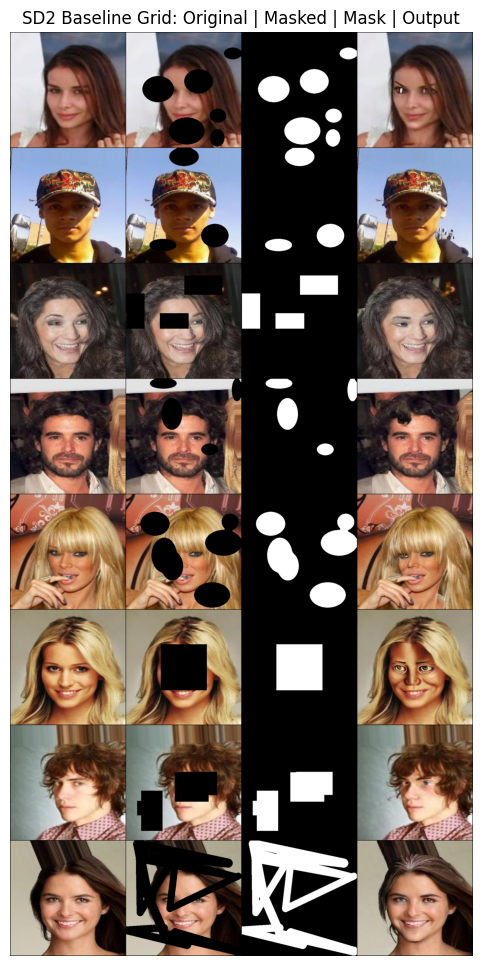

In [27]:
img = Image.open(grid_path)
plt.figure(figsize=(12, 12))
plt.imshow(img)
plt.axis("off")
plt.title("SD2 Baseline Grid: Original | Masked | Mask | Output")
plt.show()

In [28]:
masktype_to_items = {}

for item in grid_items:
    _, _, _, _, mtype, _ = item
    masktype_to_items.setdefault(mtype, []).append(item)

for mtype, items in masktype_to_items.items():
    small_tensors = []
    for orig, masked, mask_rgb, pred, _, _ in items[:4]:
        small_tensors.extend([
            pil_to_tensor_01(orig),
            pil_to_tensor_01(masked),
            pil_to_tensor_01(mask_rgb),
            pil_to_tensor_01(pred)
        ])

    if len(small_tensors) > 0:
        small_grid = utils.make_grid(torch.stack(small_tensors), nrow=4)
        small_grid_path = GRID_DIR / f"sd2_grid_{mtype}.png"
        utils.save_image(small_grid, small_grid_path)
        print("Saved:", small_grid_path)

Saved: /kaggle/working/teacher_baseline_sd2_celeba_inpainting/samples/grids/sd2_grid_blob.png
Saved: /kaggle/working/teacher_baseline_sd2_celeba_inpainting/samples/grids/sd2_grid_rect.png
Saved: /kaggle/working/teacher_baseline_sd2_celeba_inpainting/samples/grids/sd2_grid_center.png
Saved: /kaggle/working/teacher_baseline_sd2_celeba_inpainting/samples/grids/sd2_grid_brush.png


In [29]:
avg_time = df_records["inference_time_sec"].mean()
std_time = df_records["inference_time_sec"].std()

mask_stats = (
    df_records.groupby("mask_type")["mask_area_ratio"]
    .agg(["count", "mean", "std", "min", "max"])
    .reset_index()
)

mask_stats_csv = RESULT_DIR / "sd2_mask_stats.csv"
mask_stats.to_csv(mask_stats_csv, index=False)

summary = {
    "teacher_model": CFG["teacher"]["model_id"],
    "image_size": CFG["image_size"],
    "n_eval_samples": int(n_eval),
    "avg_inference_time_sec": round(float(avg_time), 4),
    "std_inference_time_sec": round(float(std_time), 4),
    "subset_manifest": str(manifest_path),
    "subset_csv": str(subset_csv_path),
    "main_grid_path": str(grid_path),
    "mask_stats_csv": str(mask_stats_csv),
    "individual_outputs_saved": int(save_individual_count)
}

summary_path = RESULT_DIR / "sd2_baseline_summary.json"
with open(summary_path, "w") as f:
    json.dump(summary, f, indent=2)

print(json.dumps(summary, indent=2))
print("Saved summary:", summary_path)
print(mask_stats)

{
  "teacher_model": "sd2-community/stable-diffusion-2-inpainting",
  "image_size": 512,
  "n_eval_samples": 64,
  "avg_inference_time_sec": 5.7935,
  "std_inference_time_sec": 0.1912,
  "subset_manifest": "/kaggle/working/teacher_baseline_sd2_celeba_inpainting/metadata/celeba_fixed_subset_manifest.json",
  "subset_csv": "/kaggle/working/teacher_baseline_sd2_celeba_inpainting/metadata/celeba_fixed_subset_filenames.csv",
  "main_grid_path": "/kaggle/working/teacher_baseline_sd2_celeba_inpainting/samples/grids/sd2_baseline_grid_main.png",
  "mask_stats_csv": "/kaggle/working/teacher_baseline_sd2_celeba_inpainting/results/sd2_mask_stats.csv",
  "individual_outputs_saved": 24
}
Saved summary: /kaggle/working/teacher_baseline_sd2_celeba_inpainting/results/sd2_baseline_summary.json
  mask_type  count      mean       std     min     max
0      blob     20  0.143170  0.055777  0.0543  0.2408
1     brush     24  0.254167  0.092961  0.0677  0.4102
2    center      5  0.160300  0.000000  0.1603  

In [30]:
!pip install -q torchmetrics[image] torch-fidelity lpips

In [31]:
from torchmetrics.image.fid import FrechetInceptionDistance
from torchmetrics.image.ssim import StructuralSimilarityIndexMeasure
from torchmetrics.image.psnr import PeakSignalNoiseRatio
import lpips

In [32]:
fid_metric = FrechetInceptionDistance(feature=2048, normalize=True).to(device)
ssim_metric = StructuralSimilarityIndexMeasure(data_range=1.0).to(device)
psnr_metric = PeakSignalNoiseRatio(data_range=1.0).to(device)
lpips_model = lpips.LPIPS(net='alex').to(device)
lpips_model.eval()

Downloading: "https://github.com/toshas/torch-fidelity/releases/download/v0.2.0/weights-inception-2015-12-05-6726825d.pth" to /root/.cache/torch/hub/checkpoints/weights-inception-2015-12-05-6726825d.pth
100%|██████████| 91.2M/91.2M [00:00<00:00, 367MB/s]


Setting up [LPIPS] perceptual loss: trunk [alex], v[0.1], spatial [off]


/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=AlexNet_Weights.IMAGENET1K_V1`. You can also use `weights=AlexNet_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Downloading: "https://download.pytorch.org/models/alexnet-owt-7be5be79.pth" to /root/.cache/torch/hub/checkpoints/alexnet-owt-7be5be79.pth


100%|██████████| 233M/233M [00:01<00:00, 213MB/s]  


Loading model from: /usr/local/lib/python3.12/dist-packages/lpips/weights/v0.1/alex.pth


LPIPS(
  (scaling_layer): ScalingLayer()
  (net): alexnet(
    (slice1): Sequential(
      (0): Conv2d(3, 64, kernel_size=(11, 11), stride=(4, 4), padding=(2, 2))
      (1): ReLU(inplace=True)
    )
    (slice2): Sequential(
      (2): MaxPool2d(kernel_size=3, stride=2, padding=0, dilation=1, ceil_mode=False)
      (3): Conv2d(64, 192, kernel_size=(5, 5), stride=(1, 1), padding=(2, 2))
      (4): ReLU(inplace=True)
    )
    (slice3): Sequential(
      (5): MaxPool2d(kernel_size=3, stride=2, padding=0, dilation=1, ceil_mode=False)
      (6): Conv2d(192, 384, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (7): ReLU(inplace=True)
    )
    (slice4): Sequential(
      (8): Conv2d(384, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (9): ReLU(inplace=True)
    )
    (slice5): Sequential(
      (10): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (11): ReLU(inplace=True)
    )
  )
  (lin0): NetLinLayer(
    (model): Sequential(
      (0): D

In [33]:
N_EVAL_METRICS = min(CFG["eval"]["n_eval_metrics"], len(test_ds))

psnr_vals = []
ssim_vals = []
lpips_vals = []

fid_metric.reset()

for i in tqdm(range(N_EVAL_METRICS), desc="SD2 metric evaluation"):
    sample = test_ds[i]
    orig = sample["image_pil"]

    mask, _, _ = sample_hybrid_mask_pil(orig.size, CFG["masking"])
    pred = run_teacher_inpaint(teacher, orig, mask, CFG["teacher"])

    orig_t = pil_to_tensor_01(orig).unsqueeze(0).to(device)
    pred_t = pil_to_tensor_01(pred).unsqueeze(0).to(device)

    mask_np = (np.array(mask) > 127).astype(np.float32)
    mask_t = torch.from_numpy(mask_np).unsqueeze(0).unsqueeze(0).to(device)
    mask_t = mask_t.repeat(1, 3, 1, 1)

    orig_region = orig_t * mask_t
    pred_region = pred_t * mask_t

    psnr_vals.append(psnr_metric(pred_region, orig_region).item())
    ssim_vals.append(ssim_metric(pred_region, orig_region).item())
    lpips_vals.append(
        lpips_model(pred_region * 2 - 1, orig_region * 2 - 1).item()
    )

    fid_metric.update(orig_t, real=True)
    fid_metric.update(pred_t, real=False)

SD2 metric evaluation:   0%|          | 0/300 [00:00<?, ?it/s]

  0%|          | 0/30 [00:00<?, ?it/s]

SD2 metric evaluation:   0%|          | 1/300 [00:06<31:19,  6.29s/it]

  0%|          | 0/30 [00:00<?, ?it/s]

SD2 metric evaluation:   1%|          | 2/300 [00:12<30:04,  6.06s/it]

...

SD2 metric evaluation:  99%|█████████▉| 298/300 [29:31<00:11,  5.94s/it]

  0%|          | 0/30 [00:00<?, ?it/s]

SD2 metric evaluation: 100%|█████████▉| 299/300 [29:37<00:05,  5.94s/it]

  0%|          | 0/30 [00:00<?, ?it/s]

SD2 metric evaluation: 100%|██████████| 300/300 [29:43<00:00,  5.94s/it]


In [44]:
results = {
    "FID": round(float(fid_metric.compute().item()), 3),
    "PSNR_masked": round(float(np.mean(psnr_vals)), 3),
    "SSIM_masked": round(float(np.mean(ssim_vals)), 3),
    "LPIPS_masked": round(float(np.mean(lpips_vals)), 3),
    "avg_inference_time_sec": round(float(avg_time), 4),
    "std_inference_time_sec": round(float(std_time), 4),
    "n_eval_metrics": int(N_EVAL_METRICS)
}

print("SD2 Evaluation Results:")
for k, v in results.items():
    print(f"{k}: {v}")

SD2 Evaluation Results:
FID: 21.97
PSNR_masked: 26.855
SSIM_masked: 0.942
LPIPS_masked: 0.04
avg_inference_time_sec: 5.7935
std_inference_time_sec: 0.1912
n_eval_metrics: 300


In [45]:
metrics_json_path = RESULT_DIR / "sd2_metrics.json"
with open(metrics_json_path, "w") as f:
    json.dump(results, f, indent=2)

print("Saved metrics:", metrics_json_path)

Saved metrics: /kaggle/working/teacher_baseline_sd2_celeba_inpainting/results/sd2_metrics.json


In [46]:
report_text = f"""
Teacher Baseline Inpainting Report
==================================

1. Experiment Overview
----------------------
Experiment type: Pretrained teacher baseline for image inpainting
Teacher model: {CFG["teacher"]["model_id"]}
Prompt used: {CFG["teacher"]["prompt"]}
Image size: {CFG["image_size"]}

2. Fixed Dataset Subset
-----------------------
Train size: {CFG["subset"]["train_size"]}
Validation size: {CFG["subset"]["val_size"]}
Test size: {CFG["subset"]["test_size"]}
Subset seed: {CFG["subset"]["seed"]}

Fixed subset manifest path:
{manifest_path}

Fixed subset CSV path:
{subset_csv_path}

3. Inference Setting
--------------------
Number of evaluated test samples: {n_eval}
Number of inference steps: {CFG["teacher"]["num_inference_steps"]}
Guidance scale: {CFG["teacher"]["guidance_scale"]}
Strength: {CFG["teacher"]["strength"]}

4. Hybrid Mask Strategy
-----------------------
The teacher baseline was evaluated using:
- rectangle masks
- brush / irregular masks
- center masks
- blob / object-like masks

Mask probabilities:
- rectangle: {CFG["masking"]["rect_prob"]}
- brush: {CFG["masking"]["brush_prob"]}
- center: {CFG["masking"]["center_prob"]}
- blob: {CFG["masking"]["blob_prob"]}

Mask area ratio range:
- minimum: {CFG["masking"]["mask_area_min_ratio"]}
- maximum: {CFG["masking"]["mask_area_max_ratio"]}

5. Runtime Statistics
---------------------
Average inference time per image (sec): {avg_time:.4f}
Standard deviation of inference time (sec): {std_time:.4f}

6. Evaluation Metrics
---------------------
FID (full image): {results.get("FID", "Not computed")}
PSNR on masked region: {results.get("PSNR_masked", "Not computed")}
SSIM on masked region: {results.get("SSIM_masked", "Not computed")}
LPIPS on masked region: {results.get("LPIPS_masked", "Not computed")}

7. Saved Output Files
---------------------
Main output grid:
{grid_path}

Mask statistics CSV:
{mask_stats_csv}

Inference log CSV:
{result_csv}

Summary JSON:
{summary_path}

Metrics JSON:
{metrics_json_path}

8. Notes
--------
This notebook evaluates Stable Diffusion 2 inpainting as a stronger teacher baseline than SD 1.5 under the same fixed subset and hybrid masking protocol.
"""

report_txt_path = RESULT_DIR / "teacher_sd2_baseline_report.txt"
with open(report_txt_path, "w") as f:
    f.write(report_text)

print(report_text)
print("Saved:", report_txt_path)


Teacher Baseline Inpainting Report

1. Experiment Overview
----------------------
Experiment type: Pretrained teacher baseline for image inpainting
Teacher model: sd2-community/stable-diffusion-2-inpainting
Prompt used: a realistic high-quality human face
Image size: 512

2. Fixed Dataset Subset
-----------------------
Train size: 10000
Validation size: 1000
Test size: 1000
Subset seed: 42

Fixed subset manifest path:
/kaggle/working/teacher_baseline_sd2_celeba_inpainting/metadata/celeba_fixed_subset_manifest.json

Fixed subset CSV path:
/kaggle/working/teacher_baseline_sd2_celeba_inpainting/metadata/celeba_fixed_subset_filenames.csv

3. Inference Setting
--------------------
Number of evaluated test samples: 64
Number of inference steps: 30
Guidance scale: 7.5
Strength: 1.0

4. Hybrid Mask Strategy
-----------------------
The teacher baseline was evaluated using:
- rectangle masks
- brush / irregular masks
- center masks
- blob / object-like masks

Mask probabilities:
- rectangle: 0.

In [47]:
DO_ZIP_RESULTS = True
results_zip_path = ZIP_DIR / "sd2_teacher_baseline_outputs.zip"

if DO_ZIP_RESULTS:
    with zipfile.ZipFile(results_zip_path, "w", compression=zipfile.ZIP_DEFLATED) as zf:
        key_files = [
            manifest_path,
            subset_csv_path,
            result_csv,
            summary_path,
            mask_stats_csv,
            metrics_json_path,
            report_txt_path,
            grid_path
        ]

        for p in key_files:
            if Path(p).exists():
                zf.write(p, arcname=Path(p).name)

    print("Saved results zip:", results_zip_path)
else:
    print("Skipping result zip.")

Saved results zip: /kaggle/working/teacher_baseline_sd2_celeba_inpainting/zips/sd2_teacher_baseline_outputs.zip


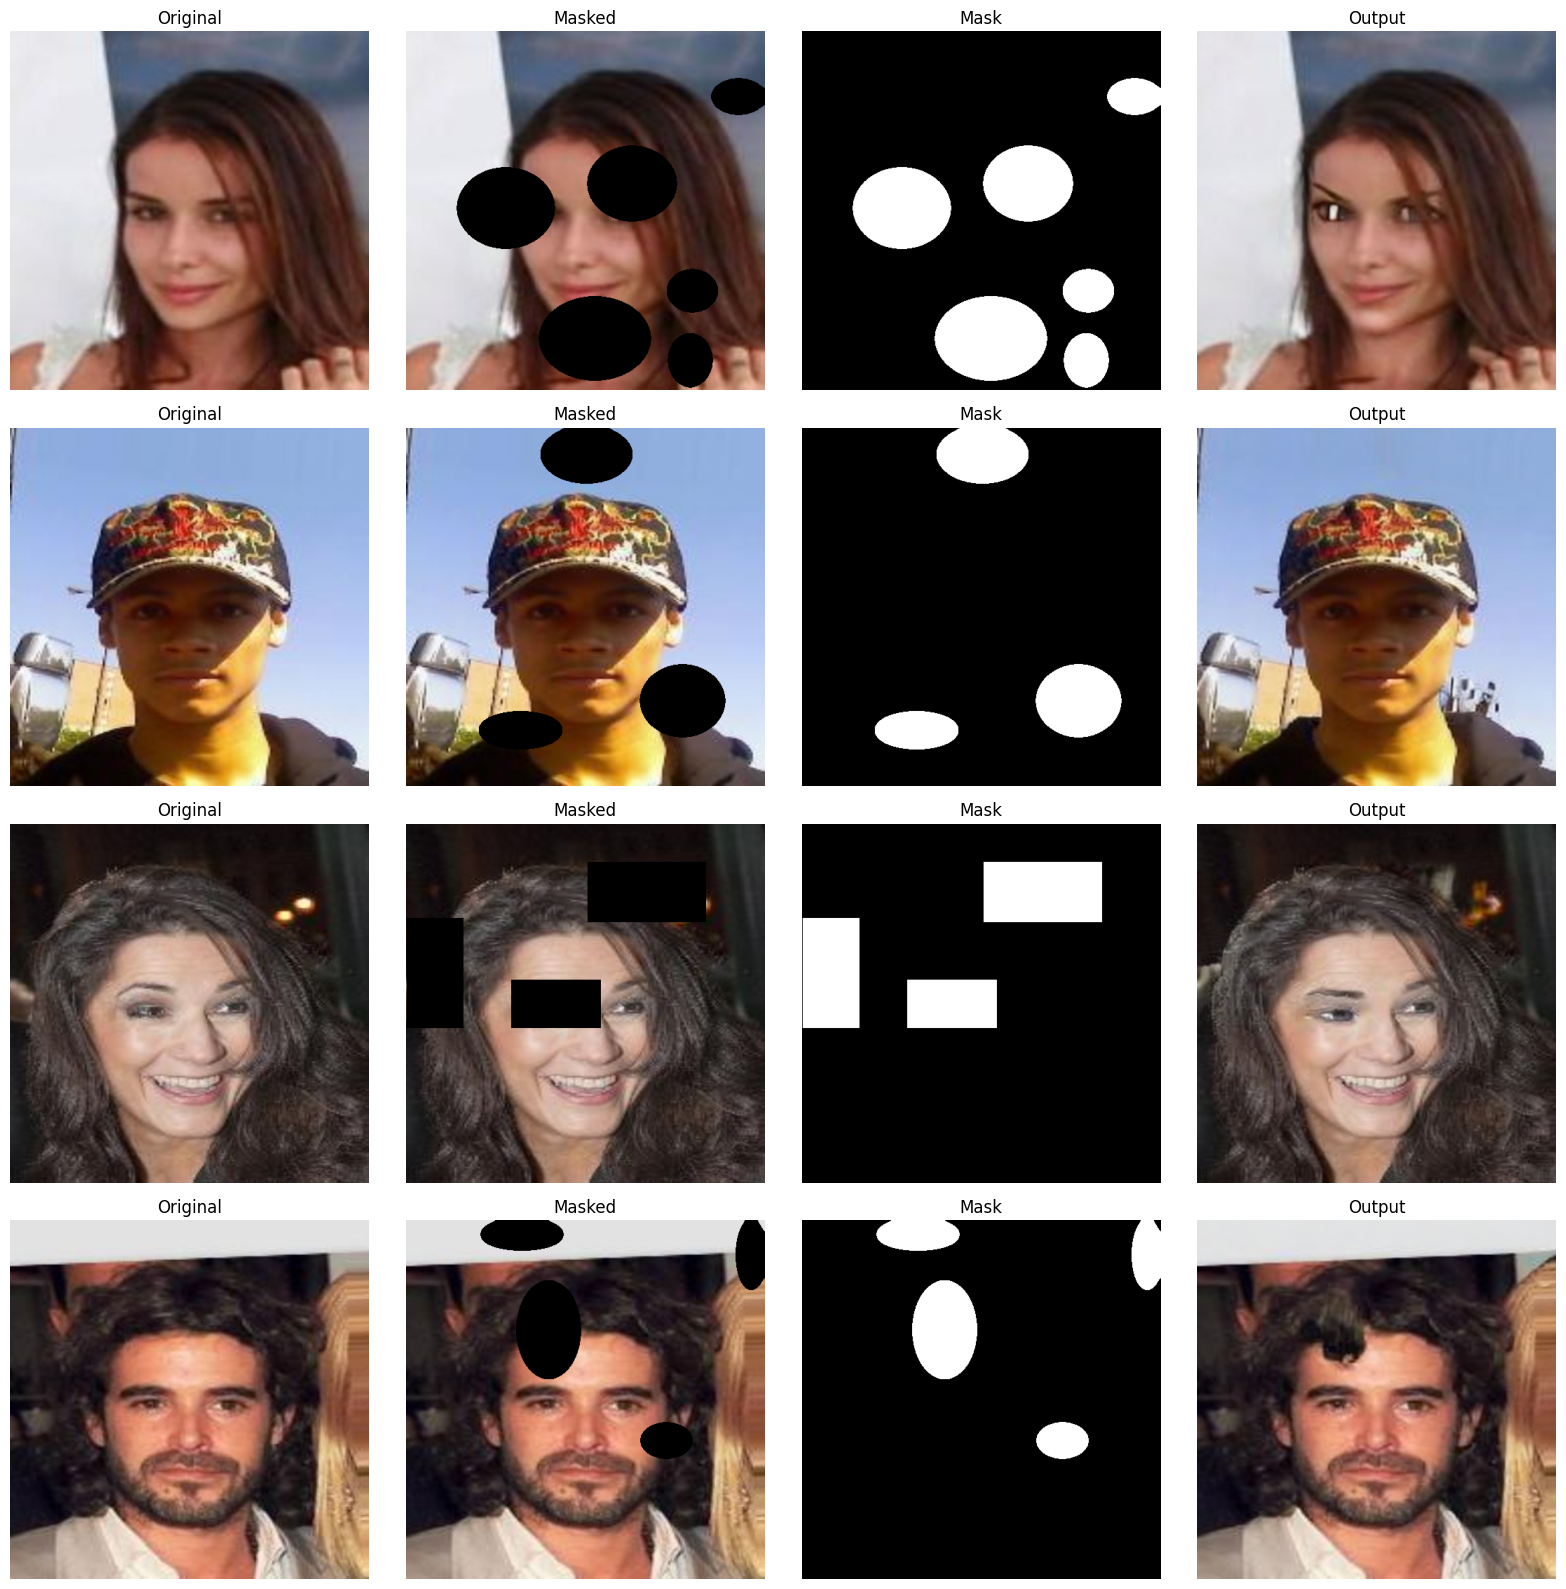

In [48]:
saved_preds = sorted(INDIV_DIR.glob("*_pred.png"))[:4]
saved_masks = sorted(INDIV_DIR.glob("*_mask.png"))[:4]
saved_masked = sorted(INDIV_DIR.glob("*_masked.png"))[:4]
saved_orig = sorted(INDIV_DIR.glob("*_orig.png"))[:4]

plt.figure(figsize=(16, 16))

for i in range(min(4, len(saved_preds))):
    orig = Image.open(saved_orig[i])
    masked = Image.open(saved_masked[i])
    mask = Image.open(saved_masks[i])
    pred = Image.open(saved_preds[i])

    row = i * 4

    plt.subplot(4, 4, row + 1)
    plt.imshow(orig)
    plt.axis("off")
    plt.title("Original")

    plt.subplot(4, 4, row + 2)
    plt.imshow(masked)
    plt.axis("off")
    plt.title("Masked")

    plt.subplot(4, 4, row + 3)
    plt.imshow(mask, cmap="gray")
    plt.axis("off")
    plt.title("Mask")

    plt.subplot(4, 4, row + 4)
    plt.imshow(pred)
    plt.axis("off")
    plt.title("Output")

plt.tight_layout()
plt.show()